In [1]:
import os
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage, HumanMessage

from langchain_classic.output_parsers import PydanticOutputParser, OutputFixingParser

load_dotenv()

True

In [62]:
# Structured schema
class SentimentSchema(BaseModel):

    sentiment: Literal['positive','negative'] = Field(description="Sentiment of the review")
    preprocessed_text: str = Field(description="Preprocess the given review")

class DiagnosisSchema(BaseModel):
    category: Literal["Account Related","Others","Enquiry Related","BuyLead Related","PNS","Mobile Application","Catalog Related","Account Deactivation",\
                      "Issue at Buyer","Payment Invoice","Account Activation","Tenders","Issue at Supplier End","Export Service","Hot Lead"] = Field(description="The Category of the given review")
    issue_type: Literal['Listing Not Visible','Irrelevant Enquiries','Irrelevant BuyLead','Services Related', 'Feedback/Suggestion'] = Field(description="The Type of issue for the given review.")
    tone: Literal['Angry','Frustrated','disappointed','Calm'] = Field(description="Tone of the given review")
    urgency: Literal['Low','Medium','High'] = Field(description="Urgency of the given review")

base_parser = PydanticOutputParser(pydantic_object=SentimentSchema)
diagnosis_parser = PydanticOutputParser(pydantic_object=DiagnosisSchema)

## Initializing LLMs

# Using models known to work well with structured output
ollama_gpt = ChatOllama(model='gpt-oss:120b-cloud')
groq = ChatGroq(model='openai/gpt-oss:120b')

## Creating model object structured output for sentiment analysis
gpt_parser = OutputFixingParser.from_llm(parser=base_parser, llm=ollama_gpt)
groq_parser = OutputFixingParser.from_llm(parser=base_parser, llm=groq)

## Creating model object structured output for diagnosis
diagnosis_parser = OutputFixingParser.from_llm(parser=diagnosis_parser, llm=ollama_gpt)

In [63]:
class ClassifySentimentInput(TypedDict):
    review: str = Field(description="Review text for which sentiment needs to be classified")
    sentiment: Literal['positive', 'negative'] = Field(description="Sentiment of the review")
    diagnosis: dict = Field(description="Get the category, issue type, tone and urgency of the user using review")
    response: str

# Func_1: To nomalize the review and get the review sentiments
def GetSentiment(state: ClassifySentimentInput)-> ClassifySentimentInput:

    prompt = f"Preprocess the given review, normalize it, remove any non-ASCII characters and Find out the sentiment of the following review: \n{state['review']}\n\n Return the preprocessed review too."

    output = gpt_parser.invoke(prompt)

    review, sentiment = output.preprocessed_text, output.sentiment

    return {'review':review, 'sentiment':sentiment}

# Func_2: To check the contition as per the observed sentiment
def check_sentiment(state: ClassifySentimentInput)->Literal["RunDiagnosis","GenerateResponse4Positive"]:

    sentiment = state['sentiment']

    if sentiment == 'positive':
        return "GenerateResponse4Positive"
    else:
        return "RunDiagnosis"
    
# Func_3: To generate a Positive response in case the review classified as positive
def GenerateResponse4Positive(state: ClassifySentimentInput)->ClassifySentimentInput:

    prompt=f"""Generate a warm Thank you Email response for the review:\n{state['review']}\n\n 
    Kindly ask the user to leave feedback on our website.
    Keep the the tone of the email professional, simplified and engaging."""

    output = ollama_gpt.invoke(prompt).content

    return {'response':output}

# Func_4: Check the review for the 'issue type', 'tone' and 'urgency'
def RunDiagnosis(state:ClassifySentimentInput)->ClassifySentimentInput:

    prompt=f"""Disgnose the given review:{state['review']}\n\n
    Check for the category, issue type, tone and urgency\n
    Return ONLY a valid output matching the schema. 
    Do NOT include any markdown formatting, do NOT include markdown code blocks (like ```json), and do NOT include any introductory or concluding text."""

    output = diagnosis_parser.invoke(prompt)

    output_dict = {"category":output.category,"issue_type":output.issue_type,"tone":output.tone,"urgency":output.urgency}

    return {'diagnosis':output_dict}

# Func_5: To generate a Negative response in case the review classified as positive
def GenerateResponse4Negative(state: ClassifySentimentInput)->ClassifySentimentInput:

    diagnosis = state['diagnosis']

    prompt=f"""You are an customer support assistant for a E-commererce platform. The user has left the following review:\n{state['review']}\n
    For following category/issue type: {diagnosis['category']}/{diagnosis['issue_type']} and
    With the following tone: {diagnosis['tone']} and with urgency level: {diagnosis['urgency']}\n
    Write an empathic, professional, and engaging email response."""

    output = ollama_gpt.invoke(prompt).content

    return {'response':output}

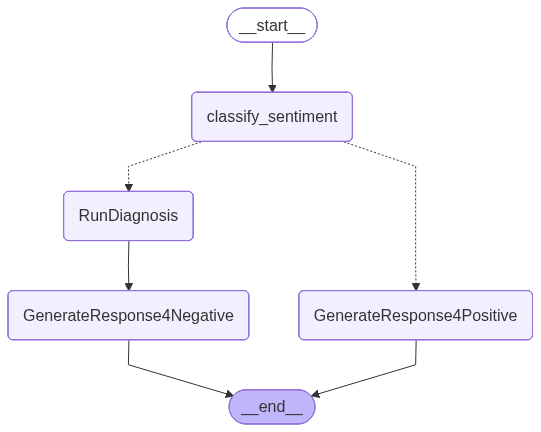

In [64]:
classifier = StateGraph(ClassifySentimentInput)

# add nodes to the graph
classifier.add_node('classify_sentiment', GetSentiment)
classifier.add_node('RunDiagnosis', RunDiagnosis)
classifier.add_node('GenerateResponse4Positive', GenerateResponse4Positive)
classifier.add_node('GenerateResponse4Negative', GenerateResponse4Negative)

# add edges
classifier.add_edge(START,'classify_sentiment')
classifier.add_conditional_edges('classify_sentiment', check_sentiment)
classifier.add_edge('GenerateResponse4Positive',END)
classifier.add_edge('RunDiagnosis','GenerateResponse4Negative')
classifier.add_edge('GenerateResponse4Negative',END)

workflow = classifier.compile()

workflow

In [61]:
initial_state = {
    "review": "Very very very very very bed sarvice bed aap Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½Ã°Å¸â€˜Å½"
}

workflow.invoke(initial_state)

{'review': 'very very very very very bed sarvice bed aap',
 'sentiment': 'negetive',
 'diagnosis': {'category': 'Mobile Application',
  'issue_type': 'Services Related',
  'tone': 'Angry',
  'urgency': 'High'},
 'response': '**Subject:** We’re Here to Fix Your Experience – Let’s Resolve This Together  \n\nDear\u202f[Customer Name],\n\nI’m really sorry to hear about the frustrations you’ve encountered with our mobile app and the service you received.\u202fReading your message, I can sense how disappointing and urgent the situation feels, and I want you to know that your concerns are our top priority right now.\n\n**What went wrong?**  \nYour feedback mentions a “very very very very very bad service” and a “bad app.” While I don’t have the exact details yet, I understand that something isn’t working the way it should—whether it’s a glitch in the app, a delayed order, or an issue with support.\n\n**How we’ll help you right now**\n\n1. **Immediate assistance:**  \n   - I’ve escalated your 

In [65]:
initial_state = {
    "review": "Good service customer oriented"
}

workflow.invoke(initial_state)

{'review': 'good service customer oriented',
 'sentiment': 'positive',
 'response': '**Subject:** Thank You for Your Kind Words!\n\nHi\u202f[Customer’s First Name],\n\nThank you so much for taking the time to share your feedback – “good service, customer oriented.”\u202fWe’re delighted to hear that our team could meet your expectations and provide the level of service you deserve.\n\nYour satisfaction is our top priority, and comments like yours motivate us to keep raising the bar. If you have a moment, we would really appreciate it if you could share your experience on our website. Your review helps other customers make informed decisions and lets us continue improving.\n\nYou can leave your feedback here: **[Insert Website Review Link]**\n\nThanks again for your support. Should you need anything else, please don’t hesitate to reach out.\n\nWarm regards,\n\n[Your Name]  \n[Your Position]  \n[Company Name]  \n[Phone] | [Email] | [Website]  '}